In [37]:
import pandas as pd
from plotnine import *
import numpy as np
import matplotlib as mpl
from mizani.transforms import symlog_trans
from plotnine.themes.themeable import axis_title_y, legend_position

mpl.rcParams['mathtext.fontset'] = 'custom'
mpl.rcParams['mathtext.rm'] = 'Libertinus Serif' # Roman
mpl.rcParams['mathtext.it'] = 'Libertinus Serif:italic' # Italic
mpl.rcParams['mathtext.bf'] = 'Libertinus Serif:bold' # Bold

In [17]:
denorm_metrics = pd.read_csv("out/metrics.csv")
denorm_metrics = denorm_metrics[(denorm_metrics["method"] == "denormalized") & (denorm_metrics["subset"] == "all")] # & (denorm_metrics["database"] == "neo4j")]
denorm_metrics = denorm_metrics[["graph","metric","value","database"]]
denorm_metrics.drop_duplicates(inplace=True, ignore_index=True)
denorm_metrics = pd.pivot(denorm_metrics, values="value", index="graph", columns=["metric","database"])
denorm_metrics

metric,$\mu_1$: NodeCount,$\mu_2$: EdgeCount,$\mu_3$: AvgNodePropCount,$\mu_4$: AvgEdgePropCount,$\mu_1$: NodeCount,$\mu_2$: EdgeCount,$\mu_3$: AvgNodePropCount,$\mu_4$: AvgEdgePropCount
database,neo4j,neo4j,neo4j,neo4j,memgraph,memgraph,memgraph,memgraph
graph,,,,,,,,
$S_\text{Lon}$,651.0,1952.0,4.992320,3.000000,651.0,1952.0,4.992320,3.000000
$S_\text{No-1}$,3.0,2.0,3.333333,0.000000,3.0,2.0,3.333333,0.000000
$S_\text{No-2}$,3.0,2.0,3.333333,0.000000,3.0,2.0,3.333333,0.000000
$S_\text{No-3}$,3.0,2.0,3.333333,0.000000,3.0,2.0,3.333333,0.000000
$S_\text{Nw}$,1035.0,3139.0,13.305314,3.432622,1035.0,3139.0,13.305314,3.432622
$S_\text{Off-1}$,2016523.0,3339267.0,9.861893,3.250993,2016523.0,3339267.0,9.861893,3.250993
$S_\text{Off-2}$,2016523.0,3339267.0,9.861893,3.250993,2016523.0,3339267.0,9.861893,3.250993
$S_\text{Off-3}$,2016523.0,3339267.0,9.861893,3.250993,2016523.0,3339267.0,9.861893,3.250993


In [18]:
denorm_metrics

metric,$\mu_1$: NodeCount,$\mu_2$: EdgeCount,$\mu_3$: AvgNodePropCount,$\mu_4$: AvgEdgePropCount,$\mu_1$: NodeCount,$\mu_2$: EdgeCount,$\mu_3$: AvgNodePropCount,$\mu_4$: AvgEdgePropCount
database,neo4j,neo4j,neo4j,neo4j,memgraph,memgraph,memgraph,memgraph
graph,,,,,,,,
$S_\text{Lon}$,651.0,1952.0,4.992320,3.000000,651.0,1952.0,4.992320,3.000000
$S_\text{No-1}$,3.0,2.0,3.333333,0.000000,3.0,2.0,3.333333,0.000000
$S_\text{No-2}$,3.0,2.0,3.333333,0.000000,3.0,2.0,3.333333,0.000000
$S_\text{No-3}$,3.0,2.0,3.333333,0.000000,3.0,2.0,3.333333,0.000000
$S_\text{Nw}$,1035.0,3139.0,13.305314,3.432622,1035.0,3139.0,13.305314,3.432622
$S_\text{Off-1}$,2016523.0,3339267.0,9.861893,3.250993,2016523.0,3339267.0,9.861893,3.250993
$S_\text{Off-2}$,2016523.0,3339267.0,9.861893,3.250993,2016523.0,3339267.0,9.861893,3.250993
$S_\text{Off-3}$,2016523.0,3339267.0,9.861893,3.250993,2016523.0,3339267.0,9.861893,3.250993


# Redundancy change table
Table 8 in the paper is based on the methods "denormalized" and "all"

In [19]:
dep_metrics = pd.read_csv("out/per_dep_metrics.csv")
#dep_metrics = dep_metrics[(dep_metrics['database']=="Neo4J") & ((dep_metrics['method'] == "denormalized") | (dep_metrics['method'] == "all"))]
dep_metrics = dep_metrics[((dep_metrics['method'] == "denormalized") | (dep_metrics['method'] == "all"))]

dep_metrics = dep_metrics[['graph','database','method','dependency','m5_max_inc_count','m6_avg_inc_count','m7_minimality']]
dep_metrics = dep_metrics.groupby(["graph","method","database"]).mean(numeric_only=True)

In [21]:
dep_metrics

m5_max_inc_count  m6_avg_inc_count  \
graph            method       database                                       
$S_\text{Lon}$   all          Memgraph          1.000000          1.000000   
                              Neo4J             1.000000          1.000000   
                 denormalized Memgraph        112.600000         36.423214   
                              Neo4J           112.600000         36.423214   
$S_\text{No-1}$  all          Memgraph          1.000000          1.000000   
                              Neo4J             1.000000          1.000000   
                 denormalized Memgraph          1.250000          1.250000   
                              Neo4J             1.250000          1.250000   
$S_\text{No-2}$  all          Memgraph          1.000000          1.000000   
                              Neo4J             1.000000          1.000000   
                 denormalized Memgraph          1.250000          1.250000   
                              Neo4J             1.250000          1.250000   
$S_\text{No-3}$  all          Memgraph          1.000000          1.000000   
                              Neo4J             1.000000          1.000000   
                 denormalized Memgraph          1.200000          1.200000   
                              Neo4J             1.200000          1.200000   
$S_\text{Nw}$    all          Memgraph          1.000000          1.000000   
                              Neo4J             1.000000          1.000000   
                 denormalized Memgraph         16.000000          5.162921   
                              Neo4J            16.000000          5.162921   
$S_\text{Off-1}$ all          Memgraph          1.000000          1.000000   
                              Neo4J             1.000000          1.000000   
                 denormalized Memgraph     264881.333333        613.066333   
                              Neo4J        264881.333333        613.066333   
$S_\text{Off-2}$ all          Memgraph          1.000000          1.000000   
                              Neo4J             1.000000          1.000000   
                 denormalized Memgraph     175898.000000        513.248456   
                              Neo4J        175898.000000        513.248456   
$S_\text{Off-3}$ all          Memgraph          1.000000          1.000000   
                              Neo4J             1.000000          1.000000   
                 denormalized Memgraph     239572.200000      21645.631621   
                              Neo4J        239572.200000      21645.631621   
$S_\text{Ts-1}$  all          Memgraph          1.000000          1.000000   
                              Neo4J             1.000000          1.000000   
                 denormalized Memgraph       6790.333333        563.933377   
                              Neo4J          6790.333333        563.933377   
$S_\text{Ts-2}$  all          Memgraph          1.000000          1.000000   
                              Neo4J             1.000000          1.000000   
                 denormalized Memgraph      11631.000000        964.816115   
                              Neo4J         11631.000000        964.816115   
$S_\text{Uni-1}$ all          Memgraph          1.000000          1.000000   
                              Neo4J             1.000000          1.000000   
                 denormalized Memgraph          3.000000          3.000000   
                              Neo4J             3.000000          3.000000   
$S_\text{Uni-2}$ all          Memgraph          1.000000          1.000000   
                              Neo4J             1.000000          1.000000   
                 denormalized Memgraph          3.000000          3.000000   
                              Neo4J             3.000000          3.000000   

                                        m7_minimality  
graph            method       database                 
$S_\text{Lon}$   all       

# Per graph metric changes
The dataframe below is the basis for table 11, which shwos a selection of those

In [67]:
per_graph_metrics = pd.read_csv("out/metrics.csv")
#per_graph_metrics = per_graph_metrics[(per_graph_metrics["database"] == "neo4j")]
per_graph_metrics = per_graph_metrics[["graph","metric","value","method","database"]]
per_graph_metrics = per_graph_metrics.round(6)
per_graph_metrics.drop_duplicates(inplace=True, ignore_index=True)
per_graph_metrics = pd.pivot(per_graph_metrics, values="value", index=["method","database","graph"], columns=["metric"])
#per_graph_metrics.to_excel("out/per_graph_changes.xlsx")
per_graph_metrics

metric                               $\mu_1$: NodeCount  $\mu_2$: EdgeCount  \
method    database graph                                                      
all       memgraph $S_\text{Lon}$                2646.0              6502.0   
                   $S_\text{No-1}$                  6.0                 6.0   
                   $S_\text{No-2}$                  8.0                 8.0   
                   $S_\text{No-3}$                  6.0                 5.0   
                   $S_\text{Nw}$                 1124.0              3969.0   
...                                                 ...                 ...   
node-left neo4j    $S_\text{Off-3}$           2017388.0           4367058.0   
                   $S_\text{Ts-1}$             579979.0           2214417.0   
                   $S_\text{Ts-2}$             579979.0           2214417.0   
                   $S_\text{Uni-1}$                 4.0                 3.0   
                   $S_\text{Uni-2}$                 5.0                 4.0   

metric                               $\mu_3$: AvgNodePropCount  \
method    database graph                                         
all       memgraph $S_\text{Lon}$                     0.783069   
                   $S_\text{No-1}$                    1.666667   
                   $S_\text{No-2}$                    2.000000   
                   $S_\text{No-3}$                    2.333333   
                   $S_\text{Nw}$                      8.296263   
...                                                        ...   
node-left neo4j    $S_\text{Off-3}$                   9.009412   
                   $S_\text{Ts-1}$                    2.996262   
                   $S_\text{Ts-2}$                    2.996262   
                   $S_\text{Uni-1}$                   1.500000   
                   $S_\text{Uni-2}$                   1.200000   

metric                               $\mu_4$: AvgEdgePropCount  
method    database graph                                        
all       memgraph $S_\text{Lon}$                     0.000000  
                   $S_\text{No-1}$                    0.000000  
                   $S_\text{No-2}$                    0.000000  
                   $S_\text{No-3}$                    0.000000  
                   $S_\text{Nw}$                      2.714790  
...                                                        ...  
node-left neo4j    $S_\text{Off-3}$                   2.485869  
                   $S_\text{Ts-1}$                    2.299598  
                   $S_\text{Ts-2}$                    2.299598  
                   $S_\text{Uni-1}$                   1.000000  
                   $S_\text{Uni-2}$                   0.750000  

[96 rows x 4 columns]

In [68]:
baseline = per_graph_metrics.xs('denormalized', level='method')
neo4j = baseline.xs('neo4j', level='database')
memgraph = baseline.xs('neo4j', level='database')

if neo4j.equals(memgraph):
        rel_diff = (per_graph_metrics.div(neo4j, level='graph') - 1) * 100
        rel_diff = rel_diff.drop('denormalized', level='method').drop("memgraph", level="database").droplevel("database")

In [69]:
rel_diff

metric                      $\mu_1$: NodeCount  $\mu_2$: EdgeCount  \
method    graph                                                      
all       $S_\text{Lon}$            306.451613          233.094262   
          $S_\text{No-1}$           100.000000          200.000000   
          $S_\text{No-2}$           166.666667          300.000000   
          $S_\text{No-3}$           100.000000          150.000000   
          $S_\text{Nw}$               8.599034           26.441542   
          $S_\text{Off-1}$            0.042548           10.259647   
          $S_\text{Off-2}$            0.251869           45.368160   
          $S_\text{Off-3}$            0.042896           30.778940   
          $S_\text{Ts-1}$          1880.429913          189.401791   
          $S_\text{Ts-2}$          2821.108874          489.401791   
          $S_\text{Uni-1}$            0.000000            0.000000   
          $S_\text{Uni-2}$           25.000000           33.333333   
edge-left $S_\text{Lon}$            304.147465          200.000000   
          $S_\text{No-1}$             0.000000            0.000000   
          $S_\text{No-2}$             0.000000            0.000000   
          $S_\text{No-3}$             0.000000            0.000000   
          $S_\text{Nw}$               0.000000            0.000000   
          $S_\text{Off-1}$            0.000000            0.000000   
          $S_\text{Off-2}$            0.000000            0.000000   
          $S_\text{Off-3}$            0.000000            0.000000   
          $S_\text{Ts-1}$          1681.747254          168.170224   
          $S_\text{Ts-2}$          2622.705339          468.170224   
          $S_\text{Uni-1}$            0.000000            0.000000   
          $S_\text{Uni-2}$            0.000000            0.000000   
node-left $S_\text{Lon}$              2.304147           33.094262   
          $S_\text{No-1}$           100.000000          200.000000   
          $S_\text{No-2}$           166.666667          300.000000   
          $S_\text{No-3}$           100.000000          150.000000   
          $S_\text{Nw}$               8.599034           26.441542   
          $S_\text{Off-1}$            0.042548           10.259647   
          $S_\text{Off-2}$            0.251869           45.368160   
          $S_\text{Off-3}$            0.042896           30.778940   
          $S_\text{Ts-1}$           198.682659           21.231566   
          $S_\text{Ts-2}$           198.682659           21.231566   
          $S_\text{Uni-1}$            0.000000            0.000000   
          $S_\text{Uni-2}$           25.000000           33.333333   

metric                      $\mu_3$: AvgNodePropCount  \
method    graph                                         
all       $S_\text{Lon}$                   -84.314527   
          $S_\text{No-1}$                  -49.999985   
          $S_\text{No-2}$                  -39.999994   
          $S_\text{No-3}$                  -30.000003   
          $S_\text{Nw}$                    -37.646996   
          $S_\text{Off-1}$                  -3.477923   
          $S_\text{Off-2}$                 -12.839513   
          $S_\text{Off-3}$                  -8.644192   
          $S_\text{Ts-1}$                  -69.929845   
          $S_\text{Ts-2}$                  -66.757341   
          $S_\text{Uni-1}$                  20.000000   
          $S_\text{Uni-2}$                  -4.000000   
edge-left $S_\text{Lon}$                   -74.617032   
          $S_\text{No-1}$                    0.000000   
          $S_\text{No-2}$                    0.000000   
          $S_\text{No-3}$                    0.000000   
          $S_\text{Nw}$                      0.000000   
          $S_\text{Off-1}$                   0.000000   
          $S_\text{Off-2}$                   0.000000   
          $S_\text{Off-3}$                   0.000000   
          $S_\text{Ts-1}$                  -68.156846   
          $S_\text{Ts-2}$   

In [70]:
plot_df = rel_diff.reset_index()
plot_df = plot_df.melt(id_vars=['method', 'graph'], var_name='metric', value_name='percentage_diff')
#plot_df = plot_df[(plot_df["graph"].str.contains("London")) | (plot_df["graph"].str.contains("Rijden"))]
plot_df

,method,graph,metric,percentage_diff
0,all,$S_\text{Lon}$,$\mu_1$: NodeCount,306.451613
1,all,$S_\text{No-1}$,$\mu_1$: NodeCount,100.000000
2,all,$S_\text{No-2}$,$\mu_1$: NodeCount,166.666667
3,all,$S_\text{No-3}$,$\mu_1$: NodeCount,100.000000
4,all,$S_\text{Nw}$,$\mu_1$: NodeCount,8.599034
...,...,...,...,...
139,node-left,$S_\text{Off-3}$,$\mu_4$: AvgEdgePropCount,-23.535086
140,node-left,$S_\text{Ts-1}$,$\mu_4$: AvgEdgePropCount,-39.289975
141,node-left,$S_\text{Ts-2}$,$\mu_4$: AvgEdgePropCount,-39.289975
142,node-left,$S_\text{Uni-1}$,$\mu_4$: AvgEdgePropCount,-50.000000


In [71]:
plot_df["metric"] = plot_df["metric"].str.slice(8,)
plot_df["node_group"] = np.where(
    plot_df["metric"].str.contains("Node"),
    "Node",
    "Edge"
)
plot_df["metric_group"] = np.where(
    plot_df["metric"].str.contains("Prop"),
    "Prop. Count",
    "Graph object count"
)
plot_df["percentage_diff"] = plot_df["percentage_diff"].fillna(0)
plot1_df=plot_df[(plot_df["method"]=="all")]
plot2_df=plot_df[(plot_df["method"]=="edge-left") & ((plot_df["graph"].str.contains("Lon")) | (plot_df["graph"].str.contains("Ts-")))]
plot3_df=plot_df[(plot_df["method"]=="node-left") & ((plot_df["graph"].str.contains("Lon")) | (plot_df["graph"].str.contains("Ts-")))]

plot1_df

,method,graph,metric,percentage_diff,node_group,metric_group
0,all,$S_\text{Lon}$,NodeCount,306.451613,Node,Graph object count
1,all,$S_\text{No-1}$,NodeCount,100.000000,Node,Graph object count
2,all,$S_\text{No-2}$,NodeCount,166.666667,Node,Graph object count
3,all,$S_\text{No-3}$,NodeCount,100.000000,Node,Graph object count
4,all,$S_\text{Nw}$,NodeCount,8.599034,Node,Graph object count
5,all,$S_\text{Off-1}$,NodeCount,0.042548,Node,Graph object count
6,all,$S_\text{Off-2}$,NodeCount,0.251869,Node,Graph object count
7,all,$S_\text{Off-3}$,NodeCount,0.042896,Node,Graph object count
8,all,$S_\text{Ts-1}$,NodeCount,1880.429913,Node,Graph object count
9,all,$S_\text{Ts-2}$,NodeCount,2821.108874,Node,Graph object count


/Users/jschrott/Repositories/global-lpg-norm/.venv/lib/python3.13/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 12.0 x 6.5 cm image.
/Users/jschrott/Repositories/global-lpg-norm/.venv/lib/python3.13/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: out/fig7a-changes-all.pdf


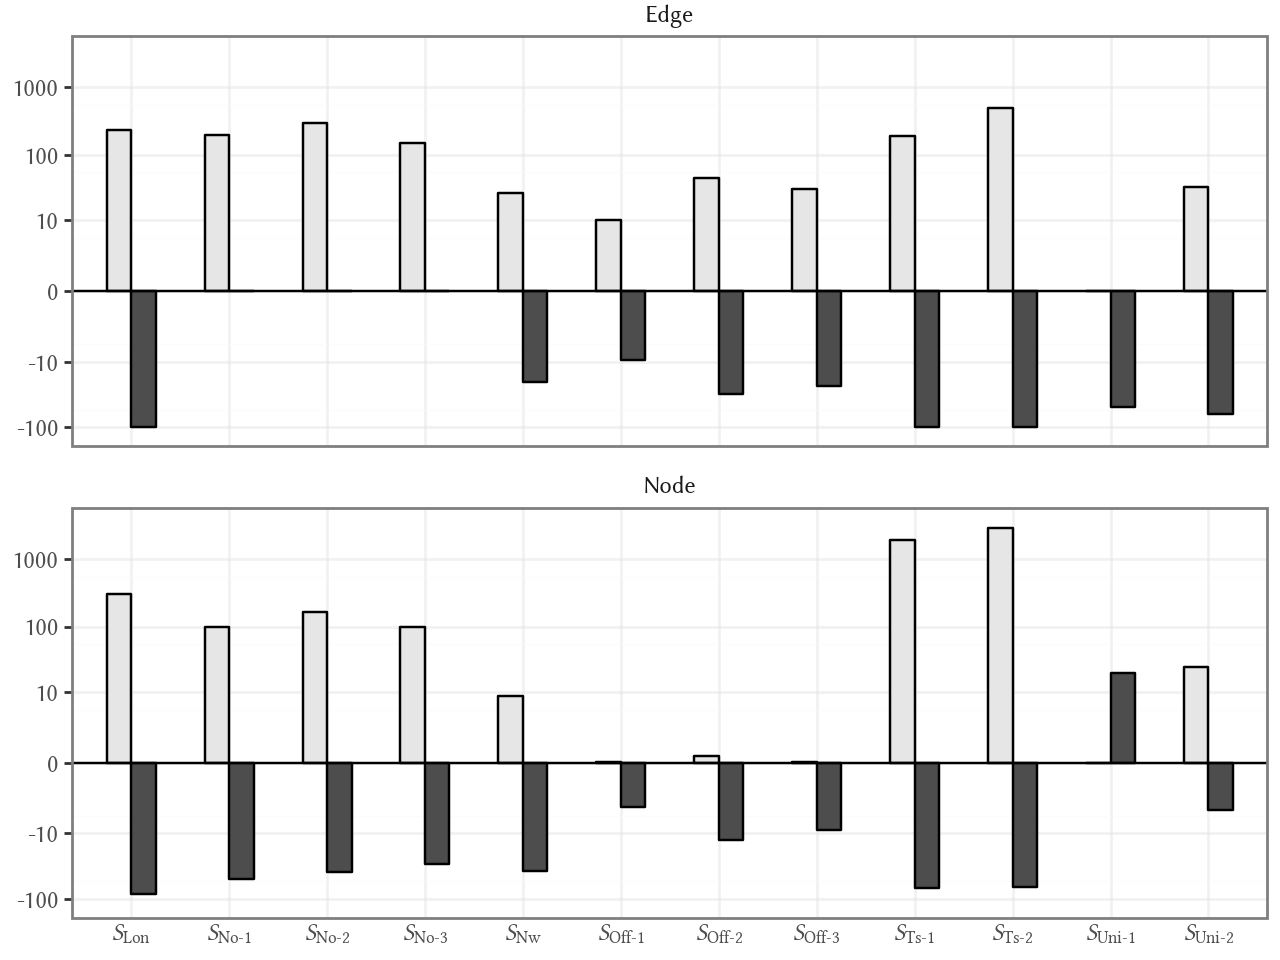

In [96]:
plot1 = (
    ggplot(plot1_df, aes(x='graph', y='percentage_diff', fill='metric_group'))
    + geom_col(color="black", position='dodge', width=0.5)
    + geom_hline(yintercept=0, color="black")
    + scale_fill_grey(start=0.9, end=0.3)
    + scale_y_continuous(trans="symlog", limits=(-100,3000))
    + facet_wrap('node_group', scales='free_y', ncol=1 )
    + labs(
        y="Percentual change to the per-graph metrics on a logarithmic scale (%)",
        x=" ",
        fill="Metric"
    )
    + theme_bw()
    + theme(text=element_text(family='Libertinus Sans'),
            plot_background=element_rect(fill='white'),
            axis_title_x=element_blank(),
            axis_title_y=element_blank(),
            axis_ticks_major_x=element_blank(),
            #legend_position="top",
            legend_position="none",
            legend_background=element_rect(
                color='gray',
                size=0.5,
                fill='white',
            ),
            legend_margin=5,
            strip_background = element_blank(),
            panel_spacing = 0.03

            )
)
plot1.save("out/fig7a-changes-all.pdf", width=12, height=6.5, units="cm")
plot1

/Users/jschrott/Repositories/global-lpg-norm/.venv/lib/python3.13/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 3.9999999999999996 x 6.5 cm image.
/Users/jschrott/Repositories/global-lpg-norm/.venv/lib/python3.13/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: out/fig7c-changes-edges.pdf
/Users/jschrott/Repositories/global-lpg-norm/.venv/lib/python3.13/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 3.9999999999999996 x 6.5 cm image.
/Users/jschrott/Repositories/global-lpg-norm/.venv/lib/python3.13/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: out/fig7b-changes-nodes.pdf


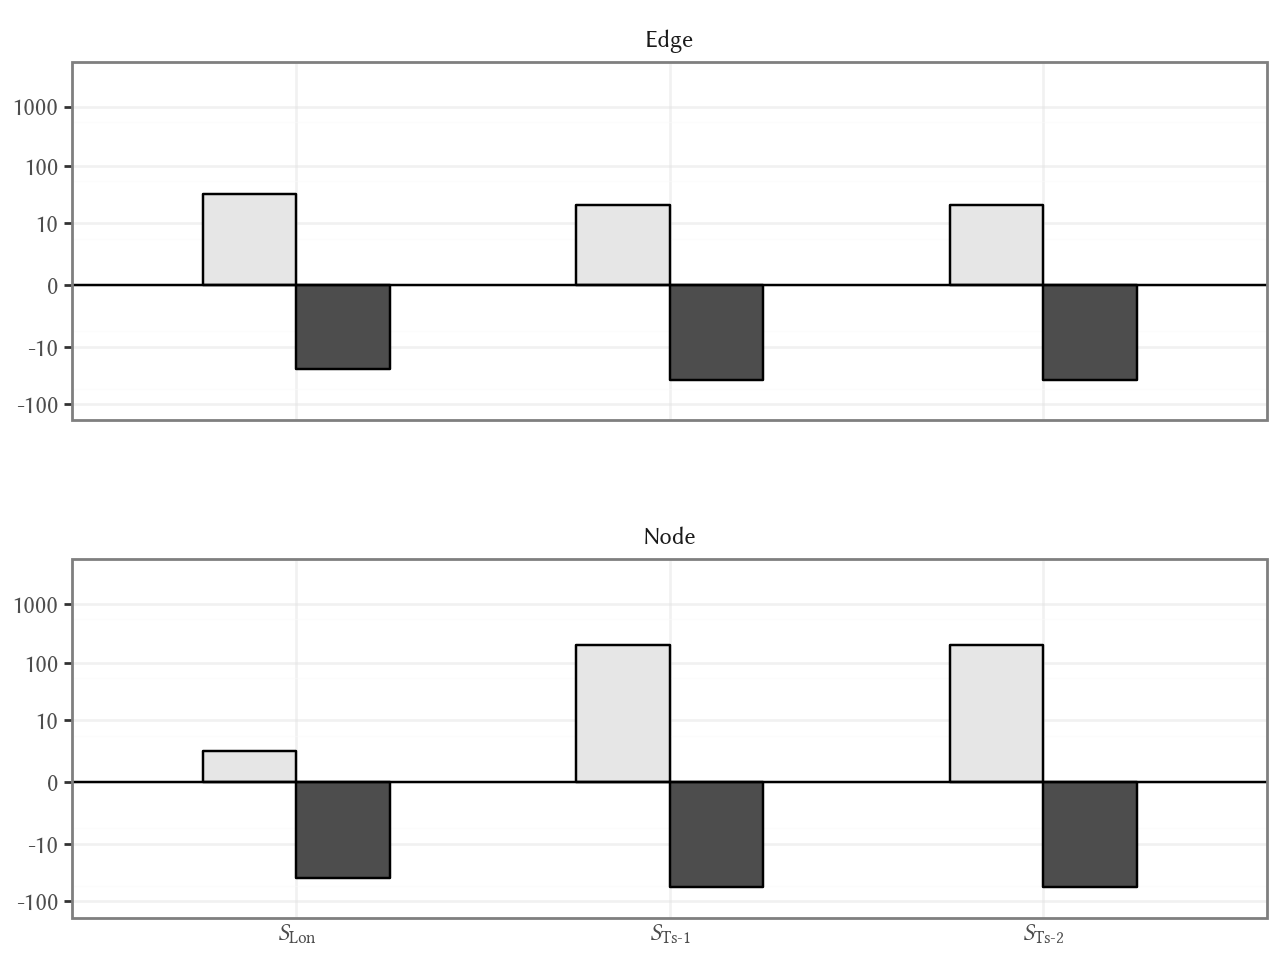

In [103]:
plot2 = (
    ggplot(plot2_df, aes(x='graph', y='percentage_diff', fill='metric_group'))
    + geom_col(color="black", position='dodge', width=0.5)
    + geom_hline(yintercept=0, color="black")
    + scale_fill_grey(start=0.9, end=0.3)
    + scale_y_continuous(trans="symlog", limits=(-100,3000))
    + facet_wrap('node_group', scales='free_y', ncol=1)
    + labs(
        y="Relative difference after normalization (%)",
        x=" ",
        fill="Statistic"
    )
    + theme_bw()
    + theme(text=element_text(family='Libertinus Sans'),
            plot_background=element_rect(fill='white'),
            axis_title=element_blank(),
            axis_ticks_major_x=element_blank(),
            legend_position='none',
                        strip_background = element_blank(),
            panel_spacing = 0.09,            legend_margin=5,
            plot_margin_top= 0.03

)
)
plot2.save("out/fig7c-changes-edges.pdf", width=4, height=6.5, units="cm")
plot3 = (
    ggplot(plot3_df, aes(x='graph', y='percentage_diff', fill='metric_group'))
    + geom_col(color="black", position='dodge', width=0.5)
    + geom_hline(yintercept=0, color="black")
    + scale_fill_grey(start=0.9, end=0.3)
    + scale_y_continuous(trans="symlog", limits=(-100,3000))
    + facet_wrap('node_group', scales='free_y', ncol=1)
    + labs(
        y="Relative difference after normalization (%)",
        x=" ",
        fill="Statistic"
    )
    + theme_bw()
    + theme(text=element_text(family='Libertinus Sans'),
            plot_background=element_rect(fill='white'),
            axis_title=element_blank(),
            axis_ticks_major_x=element_blank(),
            legend_position='none',
                        strip_background = element_blank(),
            panel_spacing = 0.09,
            legend_margin=5,
            plot_margin_top= 0.03


)
)
plot3.save("out/fig7b-changes-nodes.pdf", width=4, height=6.5, units="cm")
plot3.show()

# Time

In [57]:
per_graph_metrics = pd.read_csv("out/metrics.csv")
per_graph_metrics = per_graph_metrics[(per_graph_metrics["subset"] == "all")]
per_graph_metrics["timestamp"] = pd.to_datetime(per_graph_metrics["timestamp"])
per_graph_metrics = per_graph_metrics[["graph", "method", "timestamp","database"]]
per_graph_metrics = per_graph_metrics.groupby(["graph","method","database"], as_index=False).mean()
per_graph_metrics = pd.pivot(per_graph_metrics, values="timestamp", index=["graph","database"], columns=["method"])
per_graph_metrics["duration_in_sec"] = (per_graph_metrics["all"]-per_graph_metrics["denormalized"]).dt.total_seconds()
per_graph_metrics


method                                              all  \
graph            database                                 
$S_\text{Lon}$   memgraph 2026-04-29 00:31:23.650372352   
                 neo4j    2026-04-28 23:00:47.145108480   
$S_\text{No-1}$  memgraph 2026-05-01 15:40:38.238599936   
                 neo4j    2026-05-01 15:33:10.273937152   
$S_\text{No-2}$  memgraph 2026-05-01 15:40:40.223813632   
                 neo4j    2026-05-01 15:35:48.487845888   
$S_\text{No-3}$  memgraph 2026-05-01 15:40:43.436292096   
                 neo4j    2026-05-01 15:38:31.839635712   
$S_\text{Nw}$    memgraph 2026-04-29 00:28:35.419718912   
                 neo4j    2026-04-28 22:58:03.599240448   
$S_\text{Off-1}$ memgraph 2026-04-28 23:31:36.857485568   
                 neo4j    2026-04-28 22:22:58.728232192   
$S_\text{Off-2}$ memgraph 2026-04-28 23:51:50.397112576   
                 neo4j    2026-04-28 22:30:31.481486080   
$S_\text{Off-3}$ memgraph 2026-04-29 00:13:17.878884608   
                 neo4j    2026-04-28 22:39:16.994601728   
$S_\text{Ts-1}$  memgraph 2026-04-28 23:06:25.473772544   
                 neo4j    2026-04-28 22:03:36.101978880   
$S_\text{Ts-2}$  memgraph 2026-04-28 23:17:23.819448320   
                 neo4j    2026-04-28 22:15:25.948729088   
$S_\text{Uni-1}$ memgraph 2026-04-29 00:27:49.807182848   
                 neo4j    2026-04-28 22:44:57.110045952   
$S_\text{Uni-2}$ memgraph 2026-04-29 00:27:51.660519168   
                 neo4j    2026-04-28 22:47:34.403412736   

method                                     denormalized  duration_in_sec  
graph            database                                                 
$S_\text{Lon}$   memgraph 2026-04-29 00:31:23.540895488         0.109477  
                 neo4j    2026-04-28 23:00:45.811691520         1.333417  
$S_\text{No-1}$  memgraph 2026-05-01 15:40:38.213285632         0.025314  
                 neo4j    2026-05-01 15:33:09.099999488         1.173938  
$S_\text{No-2}$  memgraph 2026-05-01 15:40:40.193876736         0.029937  
                 neo4j    2026-05-01 15:35:47.081543424         1.406302  
$S_\text{No-3}$  memgraph 2026-05-01 15:40:43.414381312         0.021911  
                 neo4j    2026-05-01 15:38:30.391900160         1.447736  
$S_\text{Nw}$    memgraph 2026-04-29 00:28:35.381434368         0.038285  
                 neo4j    2026-04-28 22:58:02.458520320         1.140720  
$S_\text{Off-1}$ memgraph 2026-04-28 23:31:27.673208064         9.184278  
                 neo4j    2026-04-28 22:22:33.957454592        24.770778  
$S_\text{Off-2}$ memgraph 2026-04-28 23:51:16.482106112        33.915006  
                 neo4j    2026-04-28 22:28:35.200574208       116.280912  
$S_\text{Off-3}$ memgraph 2026-04-29 00:12:52.724655360        25.154229  
                 neo4j    2026-04-28 22:38:13.736727552        63.257874  
$S_\text{Ts-1}$  memgraph 2026-04-28 23:05:24.584453376        60.889319  
                 neo4j    2026-04-28 22:01:25.829996544       130.271982  
$S_\text{Ts-2}$  memgraph 2026-04-28 23:15:39.657442560       104.162006  
                 neo4j    2026-04-28 22:08:37.229751296       408.718978  
$S_\text{Uni-1}$ memgraph 2026-04-29 00:27:49.798379520         0.008803  
                 neo4j    2026-04-28 22:44:56.921199360         0.188847  
$S_\text{Uni-2}$ memgraph 2026-04-29 00:27:51.649610496         0.010909  
                 neo4j    2026-04-28 22:47:33.797548032         0.605865

## Duration of normalization for $S_\text{Lon}$
### $\psi_\text{within-n}$

In [30]:
per_graph_metrics = pd.read_csv("out/metrics.csv")
per_graph_metrics = per_graph_metrics[(per_graph_metrics["subset"] == "node-left") & (per_graph_metrics["graph"].str.contains("Lon"))]
per_graph_metrics["timestamp"] = pd.to_datetime(per_graph_metrics["timestamp"])
per_graph_metrics = per_graph_metrics[["graph", "method", "timestamp","database"]]
per_graph_metrics = per_graph_metrics.groupby(["graph","method","database"], as_index=False).mean()
per_graph_metrics = pd.pivot(per_graph_metrics, values="timestamp", index=["graph","database"], columns=["method"])
per_graph_metrics["duration_in_sec"] = (per_graph_metrics["node-left"]-per_graph_metrics["denormalized"]).dt.total_seconds()
per_graph_metrics


method                                   denormalized  \
graph          database                                 
$S_\text{Lon}$ memgraph 2026-04-29 00:32:17.552859392   
               neo4j    2026-04-28 23:01:39.827953664   

method                                      node-left  duration_in_sec  
graph          database                                                 
$S_\text{Lon}$ memgraph 2026-04-29 00:32:17.583177472         0.030318  
               neo4j    2026-04-28 23:01:40.406836480         0.578883

### $\psi_\text{within-e}$

In [31]:
per_graph_metrics = pd.read_csv("out/metrics.csv")
per_graph_metrics = per_graph_metrics[(per_graph_metrics["subset"] == "edge-left") & (per_graph_metrics["graph"].str.contains("Lon"))]
per_graph_metrics["timestamp"] = pd.to_datetime(per_graph_metrics["timestamp"])
per_graph_metrics = per_graph_metrics[["graph", "method", "timestamp","database"]]
per_graph_metrics = per_graph_metrics.groupby(["graph","method","database"], as_index=False).mean()
per_graph_metrics = pd.pivot(per_graph_metrics, values="timestamp", index=["graph","database"], columns=["method"])
per_graph_metrics["duration_in_sec"] = (per_graph_metrics["edge-left"]-per_graph_metrics["denormalized"]).dt.total_seconds()
per_graph_metrics

method                                   denormalized  \
graph          database                                 
$S_\text{Lon}$ memgraph 2026-04-29 00:33:10.231250944   
               neo4j    2026-04-28 23:02:35.047477248   

method                                      edge-left  duration_in_sec  
graph          database                                                 
$S_\text{Lon}$ memgraph 2026-04-29 00:33:10.323033344         0.091782  
               neo4j    2026-04-28 23:02:36.019792640         0.972315